# **TP1 - Sistemas de Inteligencia Artificial**
## Regresión con Modelos Lineales
#### Dataset: Properati Bs. As. 2020 ([Kaggle](https://www.kaggle.com/datasets/alejandromendivil/bsas-realstate-on-sale/))

 **Introducción teórica**

**Modelos Lineales:**

Son aquellos que tienen la forma:

$\hat{y} =\beta_0 +\beta_1 x_1 + \beta_2 x_2 + .. +\beta_n x_n$

o, vectorialmente

$\hat{y} = \vec{\beta} \cdot \vec{x}$

donde $\hat{y}$ es la predicción,
$n$ es el número de _features_ o variables predictoras, $x_i$ es el i-ésimo feature y $\vec{\beta}$ es el vector de parámetros o _pesos_ del modelo (lo que entrenamos).

**Modelos lineales regularizados:**

En los modelos lineales simples, los parámetros $\beta_i$ se ajustan minimizando el error cuadrático medio entre las predicciones y los valores reales. Sin embargo, cuando hay **muchas variables**, correlaciones fuertes entre ellas o riesgo de *overfitting*, se utilizan **términos de regularización** que penalizan la magnitud de los coeficientes, mejorando así la capacidad de generalización del modelo.

Algunos ejemplos:

- **Ridge Regression** (*L2 regularization*):  

  $\text{Loss} = \text{MSE} + \alpha \sum_{i=1}^n \beta_i^2$

  Tiende a mantener todos los coeficientes pequeños pero distintos de cero.

- **Lasso Regression** (*L1 regularization*):  

  $\text{Loss} = \text{MSE} + \alpha \sum_{i=1}^n |\beta_i|$

  Puede forzar coeficientes exactamente a cero, funcionando también como método de selección de variables.

- **Elastic Net**: combina L1 y L2, balanceando sus ventajas.



**Modelos lineales con *features* polinomiales:**

Los modelos lineales pueden extenderse para capturar relaciones **no lineales** entre las variables de entrada y la variable objetivo mediante la creación de nuevas variables que son **combinaciones polinomiales** de las originales.

Por ejemplo, con dos variables $x_1$ y $x_2$ y un polinomio de grado 2, el modelo considera:  
$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1^2 + \beta_4 x_2^2 + \beta_5 x_1 x_2
$  

Aunque la relación entre las *features* y $\hat{y}$ puede ser no lineal, el modelo sigue siendo **lineal en los parámetros** $\beta_i$, por lo que conserva las propiedades y métodos de ajuste de los modelos lineales clásicos.

Este enfoque, **combinado con regularización**, permite capturar patrones complejos sin perder el control sobre el sobreajuste.


------------------------
------------------------
**Instrucciones:**

- **No** modificar las celdas de texto.

- Resolver cada consigna en su sección correspondiente. Recuerden que lo más importante es el razonamiento y justificación de los pasos para demostrar comprensión del problema a resolver, por lo tanto **deben ir COMENTANDO en la notebook las decisiones que van tomando y las interpretaciones que hagan de los resultados**. Pueden usar las funciones que definimos en las clases.

- **ENTREGA:** Ir a Archivo > Descargar .ipynb. Este archivo .ipynb deberán subirlo al campus junto con las diapositivas en formato PDF (archivo no editable) hasta las 23:59hs del día anterior a la presentación. La presentación oral de este último documento será de manera grupal en hasta 5 minutos el día asignado durante el horario de clase (se sorteará el orden de los grupos al azar). Dado el tiempo de exposición, recomendamos un máximo de 4 diapositivas.

- **Consignas presentacion:** La presentación debe tener un máximo de 4 diapositivas y una duración aproximada de **5 minutos**. La estructura de las diapositivas debe ser la siguiente:
  1. Presentación del grupo y del problema a resolver.
  2. Datos y pre-procesamiento.
  3. Modelado.
  4. Resultados/Conclusiones.

Durante la presentación deberán explicar claramente las siguientes etapas del trabajo:
- Análisis exploratorio de datos (EDA):
Qué observaron en los datos: estructura del dataset, variables importantes, valores faltantes, distribuciones, posibles outliers y relaciones entre variables.

- Modelos y ajuste fino (tuning):
Qué modelos probaron, por qué los eligieron y cómo ajustaron sus parámetros o configuraciones para mejorar el rendimiento.

- Evaluación y testeo del modelo:
Cómo evaluaron el modelo, qué métricas utilizaron y qué resultados obtuvieron en el conjunto de test.

El objetivo de esta presentación es mostrar que realmente comprendieron el proceso que realizaron y que pueden explicarlo de manera clara.

------------------------
------------------------

# 1. Importar librerías

In [95]:
# las librerías escenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Libreria para la parte regresion
#Go permite crear graficos interactivos
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

# 2. Definición del problema

- **¿Cuál es la tarea que queremos hacer con aprendizaje automático?**
  - Predecir el precio de las propiedades.
- **¿Qué métrica de evaluación vamos a usar?**
  - Utilizaremos el RMSE (_root mean squared error_).


# 3. Cargar los datos

In [96]:
# Cargamos el dataset de Kaggle
import kagglehub
import os

path = kagglehub.dataset_download("alejandromendivil/bsas-realstate-on-sale")
csv_file_path = os.path.join(path, 'bsas_realstate_on_sale_properati_dataset_2020.csv')

df = pd.read_csv(csv_file_path) # lo guardamos en un DataFrame de pandas

# El dataset teniendo muchas filas, decidimos interesarnos unicamente a los departamentos de Capital Federal
df = df[df['l2'] == "Capital Federal"]  # Importante correr esta línea!

Using Colab cache for faster access to the 'bsas-realstate-on-sale' dataset.


Se eliminaron los duplicados, reduciendo el dataset en 1634 propiedades.  

In [97]:
print("Filas antes:", len(df))

df = df.drop_duplicates().copy()

print("Filas después:", len(df))

Filas antes: 92539
Filas después: 90905


# 4.  Crear conjunto de test

---
Primero se realiza una separación del dataset en conjuntos de entrenamiento y testeo utilizando, por ejemplo, ```train_test_split```. El conjunto de entrenamiento se utiliza para ajustar el modelo, mientras que el conjunto de prueba permite evaluar su rendimiento sobre datos que el modelo no ha visto durante el entrenamiento.

**Separación de datos**
  - Crear los conjuntos de entrenamiento y testeo `X_train`, `X_test`, `y_train`, `y_test` (sug: `train_test_split`).

In [98]:
# importamos la función train_test_split para poder utilizarla para dividir
from sklearn.model_selection import train_test_split

#Separamos las variables que usamos como datos de entrada (X) de la variable objetivo que queremos predecir (y)
X = df.drop(columns=['price'])
Y = df['price']

# Spliteamos con ayuda de la función train_test_split, el 20% de los datos para prueba y el 80% para entrenamiento (es lo estándar)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(72724, 18) (18181, 18) (72724,) (18181,)


# 5.  Análisis exploratorio de datos

---


*Antes de entrenar un modelo de aprendizaje automático, es fundamental explorar y comprender el conjunto de datos. El análisis exploratorio de datos (EDA) permite examinar la estructura del dataset, identificar los tipos de variables, detectar valores faltantes y observar la distribución de los datos. Además, ayuda a encontrar posibles valores atípicos (outliers) y a entender cómo están organizadas las diferentes variables.
En esta sección analizaremos la estructura del dataset, verificaremos la presencia de valores nulos y exploraremos las distribuciones y relaciones entre variables para asegurarnos de que los datos están listos para las etapas posteriores de modelado.*

---



Acá comienzan ustedes..
- 5.1) **Conocer los datos**
  - Explorar la estructura del dataset: cantidad de columnas y filas, tipos de datos, entender qué significa cada variable (métodos relevantes: `head()`, `info()`, `describe()`).
  - Identificar variables numéricas y categóricas.
  - Identificar si hay variables irrelevantes o redundantes.


In [99]:
X_train.head()

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,currency,title,description,property_type,operation_type
11635,2019-11-19,9999-12-31,2019-11-19,-34.645396,-58.512464,Argentina,Capital Federal,Liniers,3.0,2.0,NaN,NaN,NaN,USD,"Departamento en Venta en Liniers, Capital fede...","Venta de Departamento 3 AMBIENTES en Liniers, ...",Departamento,Venta
40341,2019-12-19,9999-12-31,2019-12-19,-34.589628,-58.418152,Argentina,Capital Federal,Palermo,5.0,4.0,3.0,348.0,202.0,USD,"PH 5 AMBIENTES, MUY LUMINOSO Y SIN EXPENSAS. P...","PH 5 ambientes, en 2 plantas, con entrada inde...",PH,Venta
62500,2019-02-14,9999-12-31,2019-02-14,-34.578159,-58.414703,Argentina,Capital Federal,Palermo,6.0,5.0,6.0,358.0,275.0,USD,Venta Departamento en Palermo Capital Federal ...,"Departamento en Venta, TRIPLEX, 5 DORMITORIOS ...",Departamento,Venta
59289,2019-11-13,9999-12-31,2019-11-13,-34.591433,-58.426073,Argentina,Capital Federal,Palermo,3.0,2.0,1.0,NaN,NaN,USD,"Departamento en Venta en Palermo, Capital fede...",VENTA DEPARTAMENTO 3 AMBIENTES PALERMO\nExcele...,Departamento,Venta
91234,2019-07-13,2020-02-26,2019-07-13,-34.601171,-58.429932,Argentina,Capital Federal,Almagro,4.0,3.0,3.0,103.0,92.0,USD,DEPARTAMENTO EN VENTA,Xintel (GOP-GOP-8392) Venta de Departamento 4 ...,Departamento,Venta


In [100]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72724 entries, 11635 to 24837
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   start_date       72724 non-null  object 
 1   end_date         72724 non-null  object 
 2   created_on       72724 non-null  object 
 3   lat              69192 non-null  float64
 4   lon              69180 non-null  float64
 5   l1               72724 non-null  object 
 6   l2               72724 non-null  object 
 7   l3               72724 non-null  object 
 8   rooms            72724 non-null  float64
 9   bedrooms         72724 non-null  float64
 10  bathrooms        70735 non-null  float64
 11  surface_total    65379 non-null  float64
 12  surface_covered  64974 non-null  float64
 13  currency         72724 non-null  object 
 14  title            72724 non-null  object 
 15  description      72724 non-null  object 
 16  property_type    72724 non-null  object 
 17  operation_typ

Se convierten a continucion los valores de fechas a su tipo de dato correspondiente.

In [101]:
X_train["start_date"] = pd.to_datetime(X_train["start_date"])
# end_date contiene valores 9999-12-31, que exceden el rango de datetime de pandas.
# Con errors="coerce" esos valores se convierten en NaT.
X_train["end_date"] = pd.to_datetime(X_train["end_date"], format="%Y-%m-%d", errors="coerce")
X_train["created_on"] = pd.to_datetime(X_train["created_on"])

X_test["start_date"] = pd.to_datetime(X_test["start_date"])
# end_date contiene valores 9999-12-31, que exceden el rango de datetime de pandas.
# Con errors="coerce" esos valores se convierten en NaT.
X_test["end_date"] = pd.to_datetime(X_test["end_date"], format="%Y-%m-%d", errors="coerce")
X_test["created_on"] = pd.to_datetime(X_test["created_on"])

In [102]:
X_train["operation_type"].value_counts()

,count
operation_type,
Venta,72724


In [103]:
X_train["property_type"].value_counts()

,count
property_type,
Departamento,62163
PH,7598
Casa,2140
Oficina,354
Lote,189
Otro,87
Cochera,87
Local comercial,82
Depósito,23


In [104]:
X_train["currency"].value_counts()

,count
currency,
USD,72724


In [105]:
X_train = X_train.drop(columns=["l1","l2","operation_type","currency"])
X_train["barrio"] = X_train["l3"].str.lower()
X_train = X_train.drop(columns=["l3"])
X_train.columns

X_test = X_test.drop(columns=["l1","l2","operation_type","currency"])
X_test["barrio"] = X_test["l3"].str.lower()
X_test = X_test.drop(columns=["l3"])
X_test.columns

Index(['start_date', 'end_date', 'created_on', 'lat', 'lon', 'rooms',
       'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'barrio'],
      dtype='object')

In [106]:
X_train.describe().T

,count,mean,min,25%,50%,75%,max,std
start_date,72724,2019-07-31 04:29:51.980638976,2019-01-01 00:00:00,2019-04-29 00:00:00,2019-07-31 00:00:00,2019-11-12 00:00:00,2020-01-25 00:00:00,NaN
end_date,63608,2019-08-31 14:40:18.261853696,2019-01-04 00:00:00,2019-06-23 00:00:00,2019-08-17 00:00:00,2019-12-07 00:00:00,2020-03-25 00:00:00,NaN
created_on,72724,2019-07-31 04:29:51.980638976,2019-01-01 00:00:00,2019-04-29 00:00:00,2019-07-31 00:00:00,2019-11-12 00:00:00,2020-01-25 00:00:00,NaN
lat,69192.0,-34.599222,-34.696419,-34.61405,-34.599546,-34.584244,-34.535818,0.024062
lon,69180.0,-58.435941,-58.530467,-58.45983,-58.433759,-58.409601,-58.35393,0.036505
rooms,72724.0,2.961031,1.0,2.0,3.0,4.0,26.0,1.330878
bedrooms,72724.0,1.956521,0.0,1.0,2.0,3.0,15.0,1.087438
bathrooms,70735.0,1.560076,1.0,1.0,1.0,2.0,14.0,0.861261
surface_total,65379.0,116.660732,10.0,49.0,71.0,112.0,126062.0,1103.160847
surface_covered,64974.0,96.961954,1.0,44.0,63.0,96.0,126062.0,870.02783


Luego del análisis exploratorio de la estructura del dataset, observamos que:

**Variables categóricas:** l1, l2, l3, currency, property_type y operation_type. Además, title y description son variables de texto.
* l1, l2, currency y operation_type presentan una única categoría en los datos analizados, por lo que no aportan información para diferenciar las observaciones y decidimos eliminarlas.

**Variables numéricas**: lat, lon, rooms, bedrooms, bathrooms, surface_total y surface_covered.

**Variables temporales:** start_date, end_date y created_on.

La variable l3 representa el barrio. A partir de ella se creó la variable barrio, pasando sus valores a minúscula para mantener un formato uniforme, y luego se eliminó l3.

- 5.2) **Valores faltantes**
  - Calcular el porcentaje de valores nulos por columna.
  - Imputar valores faltantes si hay. Decidir qué estrategia de imputación usar para variables numéricas y para categóricas (sug: `SimpleImputer`).

Vemos el porcentaje de valores faltantes para cada columna

In [107]:
X_train.isnull().mean().sort_values(ascending=False).round(3)

,0
end_date,0.125
surface_covered,0.107
surface_total,0.101
lon,0.049
lat,0.049
bathrooms,0.027
rooms,0.000
created_on,0.000
start_date,0.000
bedrooms,0.000


Para las columnas numéricas con valores faltantes que no son geográficas, decidimos utilizar *KNNImputer* con 5 vecinos. Este método estima los valores faltantes a partir de observaciones similares, utilizando rooms y bedrooms como variables de referencia.

In [108]:
X_train.columns

Index(['start_date', 'end_date', 'created_on', 'lat', 'lon', 'rooms',
       'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'barrio'],
      dtype='object')

In [109]:
from sklearn.impute import KNNImputer

# 1. Imputar bathrooms
cols_bathrooms = ["rooms", "bedrooms", "bathrooms"]
imputer_bathrooms = KNNImputer(n_neighbors=5)
X_train["bathrooms"] = imputer_bathrooms.fit_transform(X_train[cols_bathrooms])[:, -1]
X_test["bathrooms"] = imputer_bathrooms.transform(X_test[cols_bathrooms])[:, -1]

# 2. Imputar surface_total
cols_surface_total = ["rooms", "bedrooms", "bathrooms", "surface_total"]
imputer_surface_total = KNNImputer(n_neighbors=5)
X_train["surface_total"] = imputer_surface_total.fit_transform(X_train[cols_surface_total])[:, -1]
X_test["surface_total"] = imputer_surface_total.transform(X_test[cols_surface_total])[:, -1]

# 3. Imputar surface_covered usando surface_total
cols_surface_covered = ["rooms", "bedrooms", "bathrooms", "surface_total", "surface_covered"]
imputer_surface_covered = KNNImputer(n_neighbors=5)
X_train["surface_covered"] = imputer_surface_covered.fit_transform(X_train[cols_surface_covered])[:, -1]
X_test["surface_covered"] = imputer_surface_covered.transform(X_test[cols_surface_covered])[:, -1]

# 4. Asegurar que surface_covered no supere surface_total
X_train["surface_covered"] = np.minimum(X_train["surface_covered"], X_train["surface_total"])
X_test["surface_covered"] = np.minimum(X_test["surface_covered"], X_test["surface_total"])

Para latitud y longitud utilizamos la mediana según l3 que es el barrio para que tenga un sentido más lógico de imputación que la mediana general de capital federal

In [110]:
# Calculamos las medianas por barrio utilizando solo X_train
mediana_lat = X_train.groupby("barrio")["lat"].median()
mediana_lon = X_train.groupby("barrio")["lon"].median()

# Imputamos los valores faltantes de train
X_train["lat"] = X_train["lat"].fillna(X_train["barrio"].map(mediana_lat))

X_train["lon"] = X_train["lon"].fillna(X_train["barrio"].map(mediana_lon))

# Imputamos los valores faltantes de test usando las medianas calculadas en train
X_test["lat"] = X_test["lat"].fillna(X_test["barrio"].map(mediana_lat))

X_test["lon"] = X_test["lon"].fillna(X_test["barrio"].map(mediana_lon))

X_train[["lat", "lon"]].isnull().mean()

,0
lat,0.0
lon,0.0


In [111]:
#Convertimos rooms y bedrooms a enteros.
#Para bathrooms, redondeamos los valores previamente imputados y luego los convertimos a enteros.
X_train["rooms"] = X_train["rooms"].astype(int)
X_test["rooms"] = X_test["rooms"].astype(int)

X_train["bedrooms"] = X_train["bedrooms"].astype(int)
X_test["bedrooms"] = X_test["bedrooms"].astype(int)

X_train["bathrooms"] = X_train["bathrooms"].round().astype(int)
X_test["bathrooms"] = X_test["bathrooms"].round().astype(int)

Se convierten ahora porque bathrooms tenía nulos y de otra forma no podía hacerse

- 5.3) **Distribuciones de variables y valores atípicos**
  - Graficar histogramas, boxplots o violinplots para variables numéricas.
  - Identificar valores atípicos y limpiarlos de ser necesario.
  - Graficar conteos para variables categóricas (sug: `value_counts()` o `sns.countplot()`).

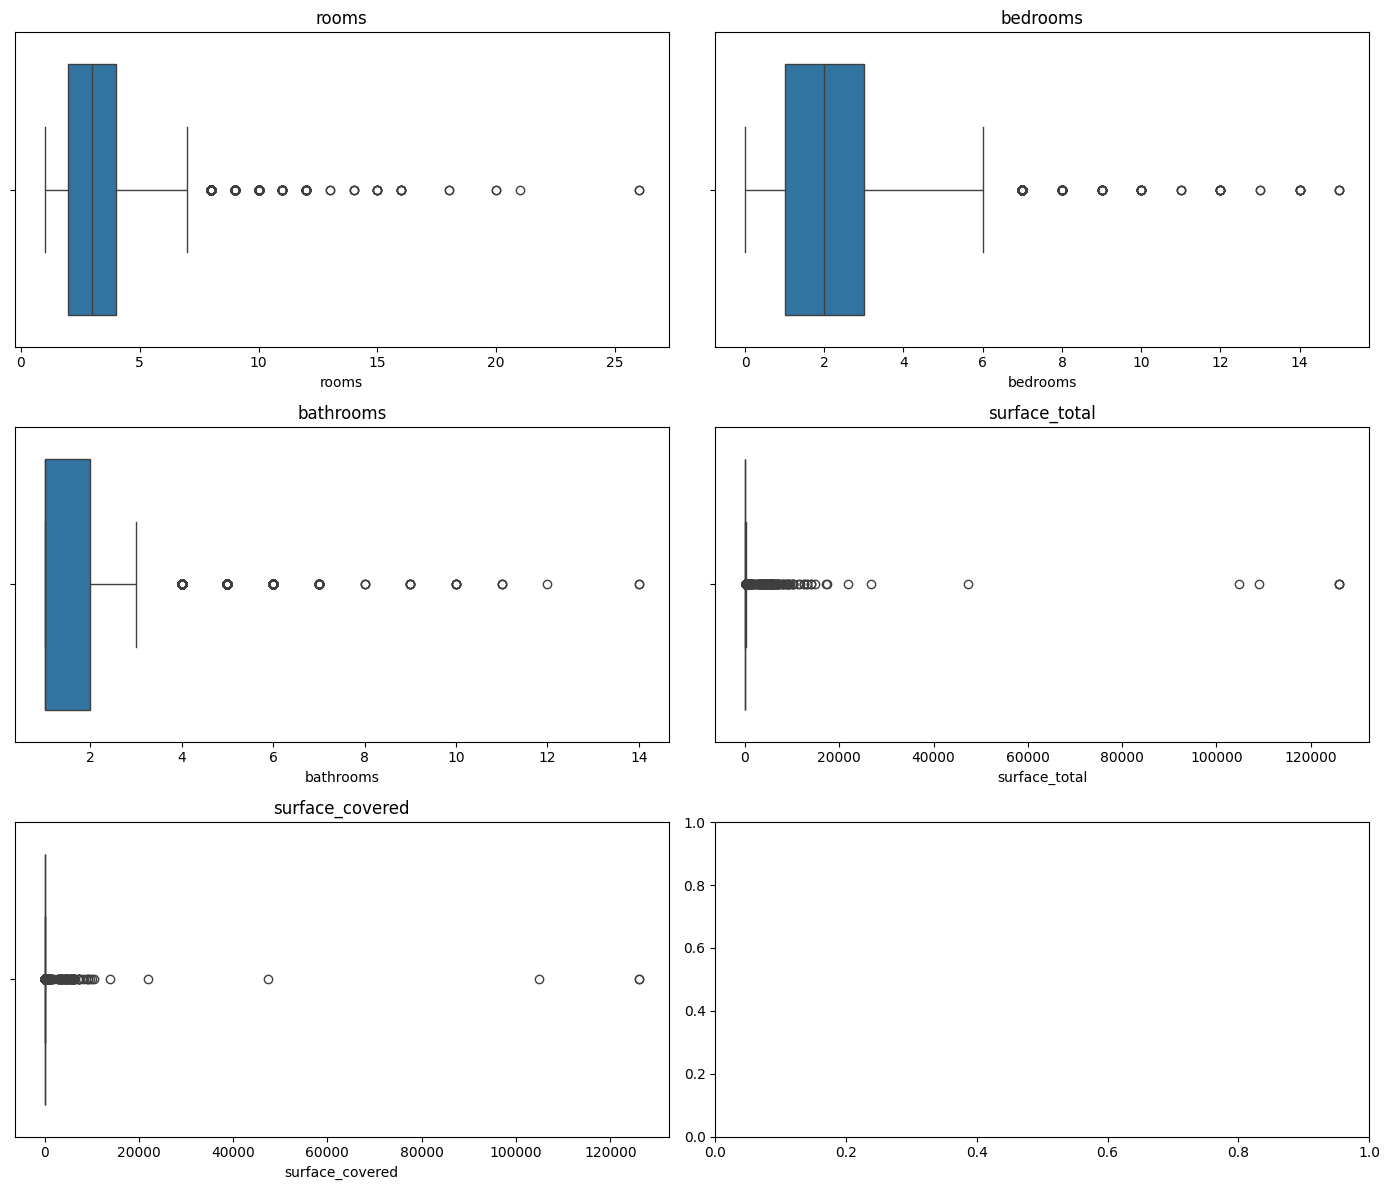

In [112]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

cols_boxplot = ["rooms", "bedrooms", "bathrooms", "surface_total", "surface_covered"]

for ax, col in zip(axes.flatten(), cols_boxplot):
    sns.boxplot(x=X_train[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Observando los boxplots se puede ver que hay una gran cantidad de outliers en la mayoría de las variables, en específico para valores altos. Por ejemplo, en surface_covered o surface_total se puede ver claramente que son 2 o 3 valores los que distorsionan por completo el gráfico al comprimir la caja a una línea. En lugar de eliminar observaciones, se recortaron los valores extremos mediante límites IQR calculados exclusivamente sobre train. Luego se aplicaron los mismos límites a test.

Se eligieron limites de 3 veces el valor del IQR, debido a que el dataset presenta departamentos grandes que no son errores de carga. Si hubiesemos usado el valor de 1,5*IQR, hubieramos recortado el dataset quitandole gran cantidad de propiedades legitimas del segmento premium, perdiendo asi informacion valiosa del mercado

In [113]:
cols_outliers = [
    "rooms",
    "bedrooms",
    "bathrooms",
    "surface_total",
    "surface_covered"
]

Q1 = X_train[cols_outliers].quantile(0.25)
Q3 = X_train[cols_outliers].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 3 * IQR
limite_sup = Q3 + 3 * IQR

X_train[cols_outliers] = X_train[cols_outliers].clip(
    lower=limite_inf,
    upper=limite_sup,
    axis=1
)

X_test[cols_outliers] = X_test[cols_outliers].clip(
    lower=limite_inf,
    upper=limite_sup,
    axis=1
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (72724, 14)
Test: (18181, 14)


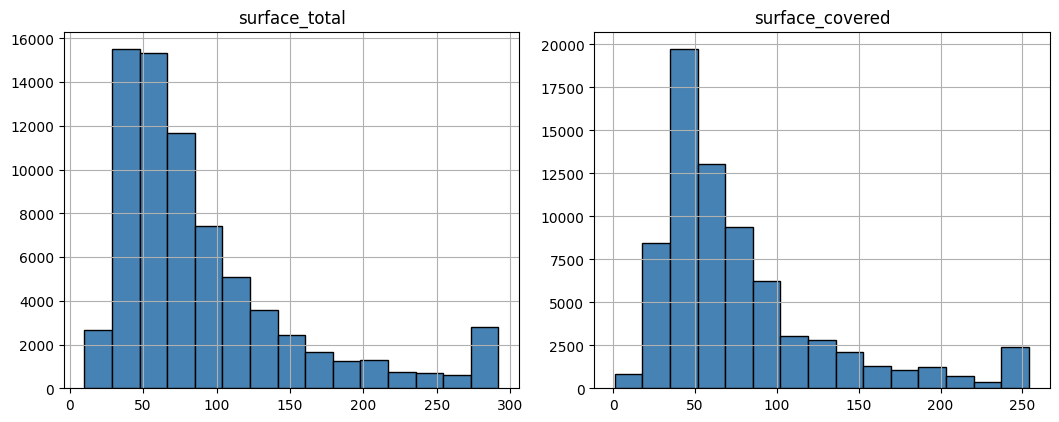

In [114]:
num_cols = ["surface_total", "surface_covered"]

X_train[num_cols].hist(figsize=(16, 12), bins=15, color="steelblue", edgecolor="black", layout=(3, 3))
plt.tight_layout()
plt.show()

Ambas variables presentan una distribución asimétrica hacia la derecha, con mayor concentración de propiedades en superficies medias y una menor cantidad de observaciones a medida que aumenta la superficie.

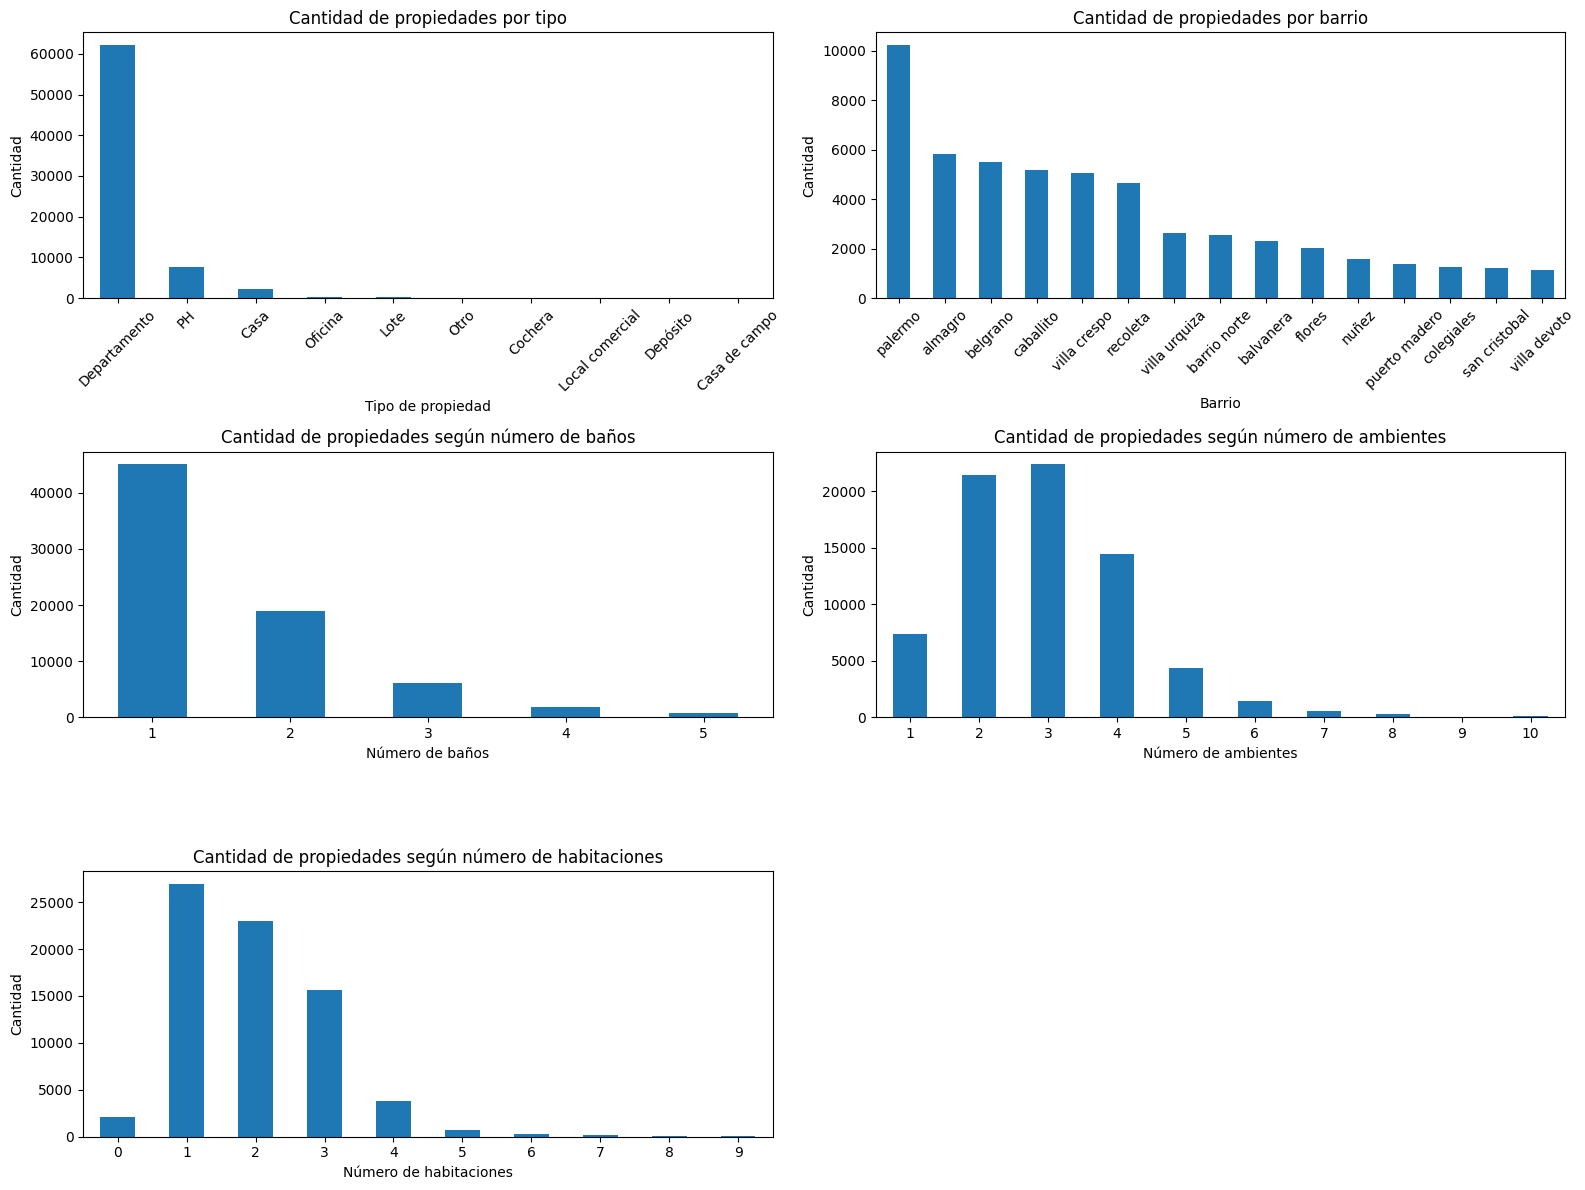

In [115]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes = axes.flatten()

X_train["property_type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Cantidad de propiedades por tipo")
axes[0].set_xlabel("Tipo de propiedad")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=45)

X_train["barrio"].value_counts().head(15).plot(kind="bar", ax=axes[1])
axes[1].set_title("Cantidad de propiedades por barrio")
axes[1].set_xlabel("Barrio")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=45)

X_train["bathrooms"].value_counts().sort_index().head(15).plot(kind="bar",ax=axes[2])
axes[2].set_title("Cantidad de propiedades según número de baños")
axes[2].set_xlabel("Número de baños")
axes[2].set_ylabel("Cantidad")
axes[2].tick_params(axis="x", rotation=0)

X_train["rooms"].value_counts().sort_index().head(15).plot(kind="bar", ax=axes[3])
axes[3].set_title("Cantidad de propiedades según número de ambientes")
axes[3].set_xlabel("Número de ambientes")
axes[3].set_ylabel("Cantidad")
axes[3].tick_params(axis="x", rotation=0)

X_train["bedrooms"].value_counts().sort_index().head(15).plot(kind="bar", ax=axes[4])
axes[4].set_title("Cantidad de propiedades según número de habitaciones")
axes[4].set_xlabel("Número de habitaciones")
axes[4].set_ylabel("Cantidad")
axes[4].tick_params(axis="x", rotation=0)

axes[5].axis("off")

plt.tight_layout()
plt.show()

Se observa un claro predominio de departamentos dentro del conjunto de datos, mientras que el resto de los tipos de propiedad tienen una presencia mucho menor. En cuanto a la ubicación, Palermo es el barrio con mayor cantidad de publicaciones, seguido por Almagro, Villa Crespo, Caballito y Belgrano. Respecto a las características de las propiedades, predominan aquellas con 1 baño, 2 o 3 ambientes y entre 1 y 2 habitaciones, mientras que las propiedades con mayor cantidad de baños, ambientes o dormitorios aparecen con mucha menor frecuencia.

- 5.4) **Relaciones entre variables**
  - Graficar diagramas de dispersión entre variables relevantes y el precio (sug: `scatterplot()`, `sns.pairplot()`).
  - Calcular matriz de correlación y visualizar (sug: `imshow` o `sns.heatmap()`).

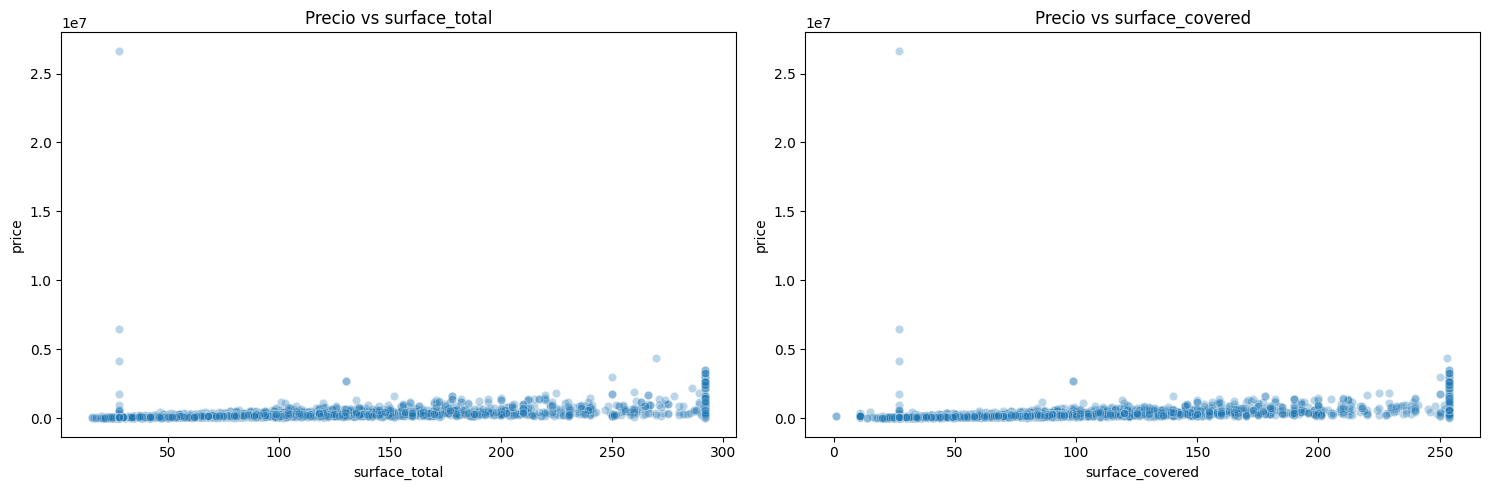

In [116]:
df_plot = X_train.copy()
df_plot["price"] = y_train.loc[df_plot.index]
df_plot = df_plot.sample(min(5000, len(df_plot)), random_state=42)

variables = ["surface_total", "surface_covered"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col in zip(axes.flatten(), variables):
    sns.scatterplot(
        data=df_plot,
        x=col,
        y="price",
        alpha=0.3,
        ax=ax)

    ax.set_title(f"Precio vs {col}")

plt.tight_layout()
plt.show()

Se observa una relacion positiva entre la superficie y el precio, aunque no es del todo lineal.
Para superficies grandes la dispersion crece mucho, hay departamentos de tamaño similar con precios muy distintos. Esto puede indicar que el precio no depende unicamente del tamaño de la propiedad, sino de otros factores (como podria ser la ubicacion).

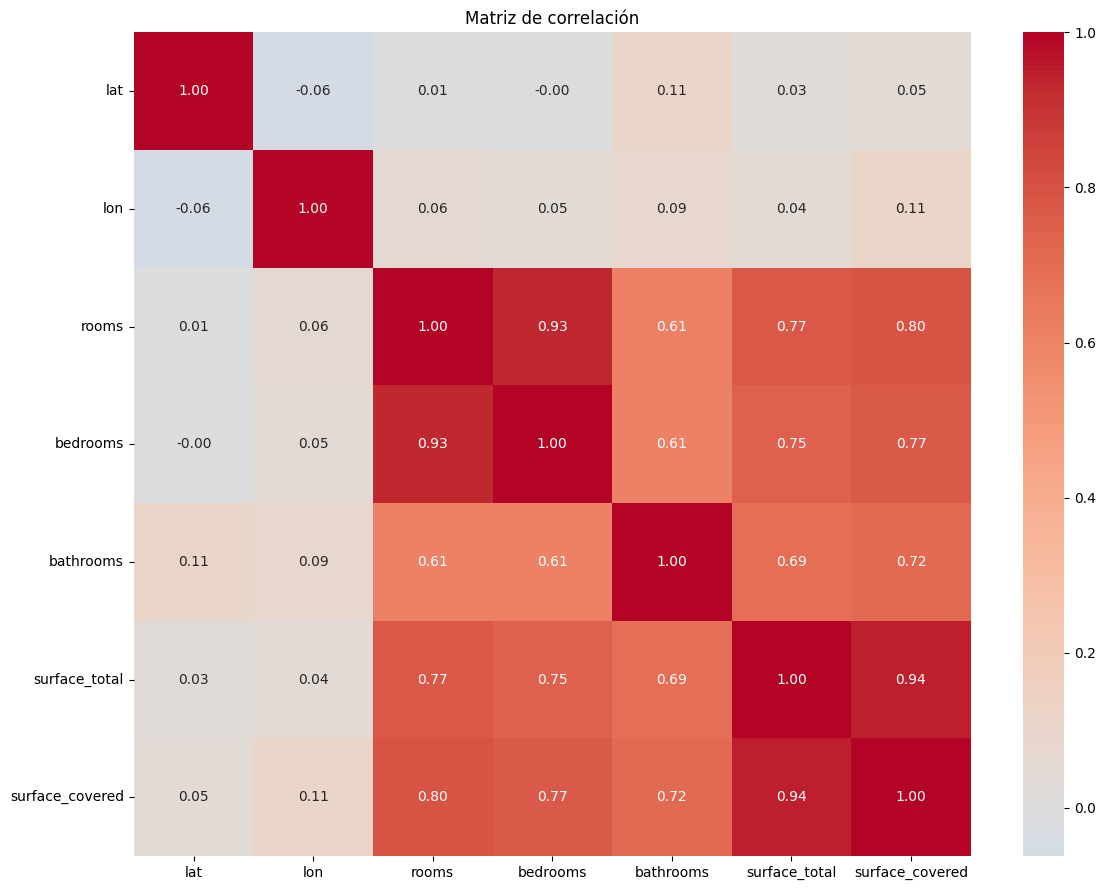

In [117]:
# Seleccionamos únicamente las variables numéricas
corr = X_train.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

En la matriz de correlacion se ven relaciones de valor muy cercano a 1 (es decir muy correlacionadas entre si). Estas son, en particular, la relacion entre surface_total y surface_covered y entre bedrooms y rooms. Esto podria generar cierta redundancia en un modelo lineal.


# 6. Preparar los datos para modelos de ML

- 6.1) **Selección de variables**
  - Opcional: Aplicar ingeniería de features (ej: transformaciones o nuevas variables a partir de las presentes).
  - Seleccionar un conjunto prometedor de variables predictoras para el entrenamiento.

In [118]:
X_train.columns

Index(['start_date', 'end_date', 'created_on', 'lat', 'lon', 'rooms',
       'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'barrio'],
      dtype='object')

In [119]:
#Seleccionamos palabras clave asociadas a amenities y características habituales de las propiedades y verificamos su presencia en los títulos y descripciones del conjunto de entrenamiento

keywords = [
    "pileta",
    "cochera",
    "balcon",
    "terraza",
    "patio",
    "jardin",
    "parrilla",
    "sum",
    "seguridad",
    "luminoso",
    "amenities",
    "gimnasio"
]

for word in keywords:
    aparece = (
        X_train["title"].str.contains(word, case=False, na=False) |
        X_train["description"].str.contains(word, case=False, na=False)
    )

    print(word, aparece.sum())

pileta 6911
cochera 24196
balcon 16143
terraza 21121
patio 12664
jardin 2464
parrilla 16626
sum 13801
seguridad 10119
luminoso 26005
amenities 9823
gimnasio 4847


In [120]:
text = ( X_train["title"].fillna("") + " " + X_train["description"].fillna("").str.lower())

keywords = [
    "pileta", "cochera", "balcon", "terraza",
    "patio", "jardin", "parrilla", "sum",
    "seguridad", "luminoso", "amenities", "gimnasio"
]

for word in keywords:
    print(word, text.str.contains(word, regex=False).sum())

pileta 6860
cochera 23716
balcon 15158
terraza 21006
patio 12586
jardin 2352
parrilla 16579
sum 13768
seguridad 10102
luminoso 25431
amenities 9273
gimnasio 4847


In [121]:
# Superficie y ambientes
X_train["cover_ratio"] = X_train["surface_covered"] / X_train["surface_total"]
X_train["uncovered_surface"] = X_train["surface_total"] - X_train["surface_covered"]
X_train["surface_per_room"] = X_train["surface_total"] / (X_train["rooms"] + 1)
X_train["lat_squared"] = X_train["lat"] ** 2
X_train["lon_squared"] = X_train["lon"] ** 2
X_train["lat_lon"] = X_train["lat"] * X_train["lon"]

# Palabras (amenities) en la descripción o título (no implica que realmente tenga el amenitie, solo que lo menciona en la descripción o título)
keywords = [
    "pileta",
    "cochera",
    "balcon",
    "terraza",
    "patio",
    "jardin",
    "parrilla",
    "sum",
    "seguridad",
    "luminoso",
    "amenities",
    "gimnasio"]

text = (X_train["title"].fillna("") + " " + X_train["description"].fillna("")).str.lower()

for word in keywords:
    X_train[f"has_{word}"] = text.str.contains(word, regex=False).astype(int)

# Fechas
X_train["start_year"] = X_train["start_date"].dt.year
X_train["start_month"] = X_train["start_date"].dt.month
X_train["start_day"] = X_train["start_date"].dt.day

Agregamos cover_ratio, uncovered_surface y surface_per_room para poder captar como se distribuye la superficie: lo que se busca es poder diferenciar caracteristicas entre departamentos de similar superfice para poder enocontrar relaciones con el precio.
Ademas sumamos lat_squared, lon_squared y lat_lon. Con estos buscamos darles al modelo un cierto margen para poder aproximar mejor esa superficie de precios por ubicacion adaptandose al modelo lineal.
Po ultimo, se definieron distintas palabras clave que se buscan en la descripcion y el titulo de la propiedad para enriquecer las caracteristicas de las propiedades. Ademas, se deja en claro que si el aviso menciona la palaba, no garantiza que esta la tenga (si menciona pileta, no es garantia de que la tenga). Sin embargo, es la unica informacion disponible y puede ser util para aportar señales en cuanto a la prediccion del precio.

In [122]:
# Superficie y ambientes
X_test["cover_ratio"] = X_test["surface_covered"] / X_test["surface_total"]
X_test["uncovered_surface"] = X_test["surface_total"] - X_test["surface_covered"]
X_test["surface_per_room"] = X_test["surface_total"] / (X_test["rooms"] + 1)
X_test["lat_squared"] = X_test["lat"] ** 2
X_test["lon_squared"] = X_test["lon"] ** 2
X_test["lat_lon"] = X_test["lat"] * X_test["lon"]


# Palabras (amenities) en la descripción o título (no implica que realmente tenga el amenitie, solo que lo menciona en la descripción o título)
keywords = [
    "pileta",
    "cochera",
    "balcon",
    "terraza",
    "patio",
    "jardin",
    "parrilla",
    "sum",
    "seguridad",
    "luminoso",
    "amenities",
    "gimnasio"]

text = (X_test["title"].fillna("") + " " + X_test["description"].fillna("")).str.lower()

for word in keywords:
    X_test[f"has_{word}"] = text.str.contains(word, regex=False).astype(int)

# Fechas
X_test["start_year"] = X_test["start_date"].dt.year
X_test["start_month"] = X_test["start_date"].dt.month
X_test["start_day"] = X_test["start_date"].dt.day

In [76]:
pip install osmnx

In [77]:
import osmnx as ox

place = "Ciudad Autónoma de Buenos Aires, Argentina"

# Educación
educacion = ox.features_from_place(place, tags={"amenity": ["school", "university"]})
colegios = educacion[educacion["amenity"] == "school"]
universidades = educacion[educacion["amenity"] == "university"]

# Salud
salud = ox.features_from_place(place, tags={"amenity": "hospital"})

# Parques
parques = ox.features_from_place(place, tags={"leisure": "park"})

# Transporte ferroviario / subte
estaciones = ox.features_from_place(place, tags={"railway": "station"})

# Comisarías
comisarias = ox.features_from_place(place, tags={"amenity": "police"})

# Comercios:
comercios = ox.features_from_place(place, tags={"shop": ["butcher", "greengrocer","supermarket"]})
supermercados = comercios[comercios["shop"] == "supermarket"]
carnicerias = comercios[comercios["shop"] == "butcher"]
verdulerias = comercios[comercios["shop"] == "greengrocer"]

In [78]:
import numpy as np
from sklearn.neighbors import BallTree

def agregar_distancia(df, lugares, nombre):
    puntos = lugares.geometry.representative_point()

    coords_lugares = np.radians(np.c_[puntos.y, puntos.x])
    coords_propiedades = np.radians(df[["lat", "lon"]])

    tree = BallTree(coords_lugares, metric="haversine")

    df[f"dist_{nombre}"] = (tree.query(coords_propiedades, k=1)[0][:, 0] * 6371000).round(2)

def agregar_cantidad_500m(df, lugares, nombre):
    puntos = lugares.geometry.representative_point()

    coords_lugares = np.radians(np.c_[puntos.y, puntos.x])
    coords_propiedades = np.radians(df[["lat", "lon"]])

    tree = BallTree(coords_lugares, metric="haversine")
    radio = 500 / 6371000

    df[f"cant_{nombre}_500m"] = tree.query_radius(coords_propiedades, r=radio, count_only=True)

In [79]:
agregar_distancia(X_train, supermercados, "supermercado")
agregar_distancia(X_train, colegios, "colegio")
agregar_distancia(X_train, universidades, "universidad")
agregar_distancia(X_train, salud, "hospital")
agregar_distancia(X_train, parques, "parque")
agregar_distancia(X_train, estaciones, "estacion_tren")
agregar_distancia(X_train, comisarias, "comisaria")
agregar_distancia(X_train, carnicerias, "carniceria")
agregar_distancia(X_train, verdulerias, "verduleria")

agregar_cantidad_500m(X_train, supermercados, "supermercado")
agregar_cantidad_500m(X_train, colegios, "colegio")
agregar_cantidad_500m(X_train, universidades, "universidad")
agregar_cantidad_500m(X_train, salud, "hospital")
agregar_cantidad_500m(X_train, parques, "parque")
agregar_cantidad_500m(X_train, estaciones, "estacion_tren")
agregar_cantidad_500m(X_train, comisarias, "comisaria")
agregar_cantidad_500m(X_train, carnicerias, "carniceria")
agregar_cantidad_500m(X_train, verdulerias, "verduleria")

agregar_distancia(X_test, supermercados, "supermercado")
agregar_distancia(X_test, colegios, "colegio")
agregar_distancia(X_test, universidades, "universidad")
agregar_distancia(X_test, salud, "hospital")
agregar_distancia(X_test, parques, "parque")
agregar_distancia(X_test, estaciones, "estacion_tren")
agregar_distancia(X_test, comisarias, "comisaria")
agregar_distancia(X_test, carnicerias, "carniceria")
agregar_distancia(X_test, verdulerias, "verduleria")

agregar_cantidad_500m(X_test, supermercados, "supermercado")
agregar_cantidad_500m(X_test, colegios, "colegio")
agregar_cantidad_500m(X_test, universidades, "universidad")
agregar_cantidad_500m(X_test, salud, "hospital")
agregar_cantidad_500m(X_test, parques, "parque")
agregar_cantidad_500m(X_test, estaciones, "estacion_tren")
agregar_cantidad_500m(X_test, comisarias, "comisaria")
agregar_cantidad_500m(X_test, carnicerias, "carniceria")
agregar_cantidad_500m(X_test, verdulerias, "verduleria")

Con el fin de capturar el efecto de la ubicacion de forma mas completa que solo con la latitud y la longitud, se bajaron de OpenStreetMap la ubicacion de distintos servicios que se consideran valiosos.
Para cada propiedad se calculo la distancia al punto mas cercano de cada categoria, y cuantos hay en un radio de 500 metros.
Esto se hizo, porque entendimos que la cercania a los servicios elegidos suele estar asociada a mejor calidad de vida en el barrio, y son factores que pueden reflejar en el precio.

In [80]:
X_train = X_train.drop(columns=["description","title","start_date","end_date","created_on"])
X_test = X_test.drop(columns=["description", "title", "start_date", "end_date", "created_on"])

Como ya estaba extraida la informacion de estas variables, se eliminaron las columnas originales

Por lógica dropeamos end_date al ser una variable que se obtiene luego de la venta por lo que podría ser una fuente de posible leakage

- 6.2) **Codificación de variables categóricas**

---


*Los modelos de aprendizaje automático trabajan principalmente con valores numéricos, por lo que las variables categóricas deben transformarse antes de poder ser utilizadas en el entrenamiento del modelo. Este proceso se conoce como codificación de variables categóricas. Existen diferentes estrategias para hacerlo. Por ejemplo, OrdinalEncoder se utiliza cuando las categorías tienen un orden natural (por ejemplo: bajo, medio, alto), mientras que OneHotEncoder se utiliza cuando las categorías no tienen un orden específico (por ejemplo: tipos de barrio o tipo de propiedad). En esta etapa será necesario identificar las variables categóricas del dataset y decidir qué método de codificación es más adecuado para cada una de ellas antes de continuar con el proceso de modelado.*

---

  - Usar `OneHotEncoder` o `OrdinalEncoder`  para variables categóricas (decidir cual).



In [81]:
X_train.columns

Index(['lat', 'lon', 'rooms', 'bedrooms', 'bathrooms', 'surface_total',
       'surface_covered', 'property_type', 'barrio', 'cover_ratio',
       'uncovered_surface', 'surface_per_room', 'lat_squared', 'lon_squared',
       'lat_lon', 'has_pileta', 'has_cochera', 'has_balcon', 'has_terraza',
       'has_patio', 'has_jardin', 'has_parrilla', 'has_sum', 'has_seguridad',
       'has_luminoso', 'has_amenities', 'has_gimnasio', 'start_year',
       'start_month', 'start_day', 'dist_supermercado', 'dist_colegio',
       'dist_universidad', 'dist_hospital', 'dist_parque',
       'dist_estacion_tren', 'dist_comisaria', 'dist_carniceria',
       'dist_verduleria', 'cant_supermercado_500m', 'cant_colegio_500m',
       'cant_universidad_500m', 'cant_hospital_500m', 'cant_parque_500m',
       'cant_estacion_tren_500m', 'cant_comisaria_500m',
       'cant_carniceria_500m', 'cant_verduleria_500m'],
      dtype='object')

In [82]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["property_type", "barrio"]
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# TRAIN
encoded_train = encoder.fit_transform(X_train[cat_cols])
encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)
X_train = X_train.drop(columns=cat_cols)
X_train = pd.concat([X_train, encoded_train_df], axis=1)

# TEST
encoded_test = encoder.transform(X_test[cat_cols])
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(cat_cols), index=X_test.index)
X_test = X_test.drop(columns=cat_cols)
X_test = pd.concat([X_test, encoded_test_df], axis=1)

Se uso OneHotEconder para estas dos variables, pues no tienen un orden natural: PH no es mayor que casa, o un barrio no es mayor que otro.
Con OrdinalEncoder, se hubiera interpretado un orden que no existe entre categorias, pudiendo introducir una relacion falsa.

- 6.3) **Escalado de variables numéricas**
---

*Luego se aplica el escalado de las variables numéricas, por ejemplo mediante ```StandardScaler```. Este paso es importante porque muchas variables pueden estar en escalas muy diferentes (por ejemplo, superficie en metros cuadrados frente a número de baños). El escalado permite que las variables tengan una distribución comparable, lo que facilita el aprendizaje del modelo y mejora la estabilidad de algunos algoritmos.*

*Es fundamental realizar el escalado después de separar los datos. El escalador debe ajustarse únicamente utilizando el conjunto de entrenamiento (fit), y luego aplicarse tanto al conjunto de entrenamiento como al de prueba (transform). De esta manera se evita que el modelo tenga acceso indirecto a información del conjunto de prueba durante el entrenamiento, lo que podría generar una evaluación demasiado optimista del rendimiento del modelo (problema conocido como data leakage).*

---
  - Normalizar las variables numéricas (sug: `StandardScaler`).

In [83]:
X_train.columns

Index(['lat', 'lon', 'rooms', 'bedrooms', 'bathrooms', 'surface_total',
       'surface_covered', 'cover_ratio', 'uncovered_surface',
       'surface_per_room',
       ...
       'barrio_villa general mitre', 'barrio_villa lugano',
       'barrio_villa luro', 'barrio_villa ortuzar', 'barrio_villa pueyrredón',
       'barrio_villa real', 'barrio_villa riachuelo',
       'barrio_villa santa rita', 'barrio_villa soldati',
       'barrio_villa urquiza'],
      dtype='object', length=113)

In [84]:
num_cols = [
    "lat",
    "lon",
    "lat_squared",
    "lon_squared",
    "lat_lon",
    "rooms",
    "bedrooms",
    "bathrooms",
    "surface_total",
    "surface_covered",
    "surface_per_room",
    "cover_ratio",
    "uncovered_surface",
    "start_year",
    "start_month",
    "start_day",
    "dist_supermercado",
    "dist_colegio",
    "dist_universidad",
    "dist_hospital",
    "dist_parque",
    "dist_estacion_tren",
    "dist_comisaria",
    "dist_carniceria",
    "dist_verduleria",
    "cant_supermercado_500m",
    "cant_colegio_500m",
    "cant_universidad_500m",
    "cant_hospital_500m",
    "cant_parque_500m",
    "cant_estacion_tren_500m",
    "cant_comisaria_500m",
    "cant_carniceria_500m",
    "cant_verduleria_500m"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Se dejaron de lado las columnas dummy del One-Hot Encoding y las varables que ya son binarias.

In [85]:
X_train.head()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,cover_ratio,uncovered_surface,surface_per_room,...,barrio_villa general mitre,barrio_villa lugano,barrio_villa luro,barrio_villa ortuzar,barrio_villa pueyrredón,barrio_villa real,barrio_villa riachuelo,barrio_villa santa rita,barrio_villa soldati,barrio_villa urquiza
11635,-1.941792,-2.120886,0.032403,0.041653,-0.657093,0.243639,0.127220,-0.565705,0.392330,0.489367,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40341,0.390075,0.470103,1.564567,1.900039,1.747558,3.181357,2.340294,-1.269835,3.489641,2.675795,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62500,0.869629,0.564862,2.330649,2.829231,4.152208,3.181357,3.322203,-0.060836,1.128055,1.985369,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59289,0.314601,0.252492,0.032403,0.041653,-0.657093,-0.364821,-1.270113,-4.891241,2.009108,-0.463989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91234,-0.092612,0.146491,0.798485,0.970846,1.747558,0.186596,0.263177,0.097625,-0.098153,-0.111446,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 7. Entrenamiento

- 7.1) **Probar 3 modelos**
  - Regresión lineal (`LinearRegression`).
  - Regresión lineal regularizada (`Ridge` o `Lasso`).
  - Regresión polinomial regularizada (combinando `PolynomialFeatures` con `Ridge` o `Lasso`).
  - Ir siempre de lo más simple a lo más complejo.


In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

variables_polinomiales = ["rooms", "bedrooms", "bathrooms", "surface_total", "surface_covered"]

In [87]:
# Modelo 1: Regresión lineal
modelo_lineal = Pipeline([("modelo", LinearRegression())])
modelo_lineal.fit(X_train, y_train)

Pipeline(steps=[('modelo', LinearRegression())])

Se usa como baseline sin aplicarle regularizacion ni transformaciones. Sirve para tener un piso de comparacion contra el que se mediran las mejoras realizadas a partir de este punto. Es el modelo mas simple posible.

In [88]:
# Modelo 2: Ridge
modelo_ridge = Pipeline([("modelo", Ridge(alpha=1.0))])
modelo_ridge.fit(X_train, y_train)

Pipeline(steps=[('modelo', Ridge())])

La regularizacion L2 ayuda a controlar el sobreajuste y la multicolinealdad.

In [89]:
# Modelo 3: Regresión polinomial + Ridge
features_poly = ColumnTransformer([("poly", PolynomialFeatures(degree=2, include_bias=False), variables_polinomiales)], remainder="passthrough")
modelo_polinomial_ridge = Pipeline([("features", features_poly), ("modelo", Ridge(alpha=1.0))])
modelo_polinomial_ridge.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('features',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('poly',
                                                  PolynomialFeatures(include_bias=False),
                                                  ['rooms', 'bedrooms',
                                                   'bathrooms', 'surface_total',
                                                   'surface_covered'])])),
                ('modelo', Ridge())])

Buscmos captar relaciones no lineales entre las variables estructurales y el precio. Se restringen el polynomialFeatures a las 5 variables definidas, porque sino la cantidad de features explotaria. Ademas se mantiene Ridge para controlar la complejidad extra.



- 7.2) **Evaluar y comparar**
  - Evaluar los modelos **solo** en el conjunto de validación usando `cross_val_score`.

In [128]:
#Creamos copias con solo variables numéricas y booleanas para poder entrenar los modelos sin perder la información original de X_train y X_test.
(X_train["created_on"] == X_train["start_date"]).mean()

X_train_modelo = X_train.select_dtypes(include=["number", "bool"]).copy()

X_test_modelo = X_test[X_train_modelo.columns].copy()

In [129]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

metricas = {
    "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

modelos = {
    "Regresión lineal": modelo_lineal,
    "Ridge": modelo_ridge,
    "Polinomial + Ridge": modelo_polinomial_ridge}

resultados = []

for nombre, modelo in modelos.items():
    scores = cross_validate(modelo, X_train_modelo, y_train, cv=cv, scoring=metricas, n_jobs=-1)

    resultados.append({
        "Modelo": nombre,
        "RMSE promedio": -scores["test_RMSE"].mean(),
        "Desvío RMSE": scores["test_RMSE"].std(),
        "R2 promedio": scores["test_R2"].mean(),
        "Desvío R2": scores["test_R2"].std()})

resultados_cv = (pd.DataFrame(resultados).sort_values("RMSE promedio").reset_index(drop=True))
resultados_cv

,Modelo,RMSE promedio,Desvío RMSE,R2 promedio,Desvío R2
0,Polinomial + Ridge,253140.305389,51084.030684,0.489377,0.102597
1,Regresión lineal,260149.717697,49072.130583,0.460621,0.093921
2,Ridge,262187.294315,48817.624600,0.452096,0.092705


En la validacio cruzadad, podemos observar que el modelo que queda rimero es el polinomial + ridge, sacando una diferencia de R2 promedio de 0,03 con el segundo mejor modelo (regresion lineal) y teniendo menos RMSE que los otros dos modelos. Este es muy poco superior al ridge, pero presenta un RMSE levemente menor.
Los resultados sugieren que existe algo de relacion no lineal entre los datos que vale la pena capturar.

# 8. Ajuste fino



- 8.1) **Buscar los mejores hiperparámetros**
  - Para los modelos con hiperparámetros (como `alpha`  y/o `degree`), hacer un ajuste fino por validación cruzada (sug: `GridSearch` o `RandomizedSearch`).
  - Elegir **un modelo final** basandose en las métricas de validación cruzada. Hacer un gráfico de barras comparando el RMSE de validación de los modelos comparados.
  - Especificar cuál es el modelo elegido, sus hiperparámetros y variables de entrada (*features*).


In [90]:
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-5, 1, 12)
metricas = {"RMSE": "neg_root_mean_squared_error", "R2": "r2"}

# Ajuste de Ridge
grid_ridge = GridSearchCV(
    modelo_ridge,
    {"modelo__alpha": alphas},
    cv=cv,
    scoring=metricas,
    refit="RMSE",
    n_jobs=2)

grid_ridge.fit(X_train, y_train)

# Ajuste de Polinomial + Ridge
grid_poly = GridSearchCV(
    modelo_polinomial_ridge,
    {"features__poly__degree": [2, 3, 4, 5, 6, 7], "modelo__alpha": alphas},
    cv=cv,
    scoring=metricas,
    refit="RMSE",
    n_jobs=2)
grid_poly.fit(X_train, y_train)

lineal = resultados_cv[resultados_cv["Modelo"] == "Regresión lineal"].iloc[0]

indice_ridge = grid_ridge.best_index_
indice_poly = grid_poly.best_index_

comparacion_tuning = pd.DataFrame([
    ["Regresión lineal", lineal["RMSE promedio"], lineal["R2 promedio"], "Sin hiperparámetros"],
    ["Ridge", -grid_ridge.best_score_, grid_ridge.cv_results_["mean_test_R2"][indice_ridge], grid_ridge.best_params_],
    ["Polinomial + Ridge", -grid_poly.best_score_, grid_poly.cv_results_["mean_test_R2"][indice_poly], grid_poly.best_params_]],
    columns=["Modelo", "RMSE validación", "R2 validación", "Hiperparámetros"])

comparacion_tuning = (comparacion_tuning.sort_values("RMSE validación").reset_index(drop=True))

modelos_finales = {
    "Regresión lineal": modelo_lineal,
    "Ridge": grid_ridge.best_estimator_,
    "Polinomial + Ridge": grid_poly.best_estimator_}

mejor_nombre = comparacion_tuning.loc[0, "Modelo"]
modelo_final = modelos_finales[mejor_nombre]
X_train_final = X_train

comparacion_tuning

,Modelo,RMSE validación,R2 validación,Hiperparámetros
0,Polinomial + Ridge,240032.514688,0.540594,"{'features__poly__degree': 3, 'modelo__alpha':..."
1,Ridge,250109.416971,0.501404,{'modelo__alpha': 1e-05}
2,Regresión lineal,250110.303127,0.501400,Sin hiperparámetros


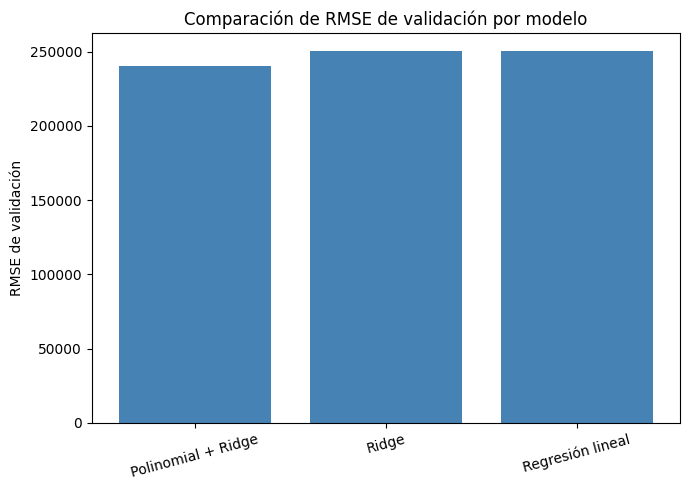

In [91]:
plt.figure(figsize=(7, 5))
plt.bar(comparacion_tuning["Modelo"], comparacion_tuning["RMSE validación"], color="steelblue")
plt.ylabel("RMSE de validación")
plt.title("Comparación de RMSE de validación por modelo")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Luego del Fine Tuning, el modelo elegido fue el Polinomial + Ridge, con degree=3 y aplpha =1e-05.

# 9. Testeo

- 9.1) **Finalmente, evaluar el modelo final en el conjunto de testeo para medir el error de generalización**
  - Calcular el RMSE del modelo final (en test) y visualizar predicciones vs valores reales en un scatterplot.
  - ¿Cuáles fueron las features más importantes?, ¿Pueden hacer alguna interpretación?
  - ¿Pueden decir algo sobre los errores que comete el modelo?

RMSE en test: 173945.75
R² en test: 0.6635


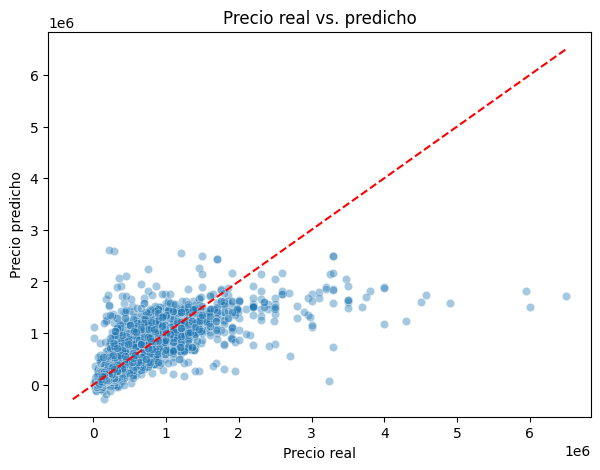

In [92]:
from sklearn.metrics import mean_squared_error, r2_score

# Predicciones sobre test
y_pred = modelo_final.predict(X_test)

# Métricas
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print(f"RMSE en test: {rmse_test:.2f}")
print(f"R² en test: {r2_test:.4f}")

# Valores reales vs. predicciones
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)

limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]

plt.plot(limites, limites, "--", color="red")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precio real vs. predicho")
plt.show()

El modelo final obtuvo un RMSE en test de 173759,81 y un R2 de 0,6643. Algo interesante es que el R2 del test fue mas alto que el de validacion (0,541). Esto es poco comun, ya que el rendimiento de test suele ser levemente peor al de validacion.
Esto puede deberse a como cayo la sepaacion entre train y test.

In [93]:
# Extraemos la regresión del pipeline
regresion = modelo_final.named_steps["modelo"]

# Obtenemos los nombres de las variables
if "features" in modelo_final.named_steps:
    nombres = (
        modelo_final
        .named_steps["features"]
        .get_feature_names_out()
    )
else:
    nombres = X_train.columns

# Armamos una tabla con los coeficientes
coeficientes = pd.DataFrame({
    "Feature": nombres,
    "Coeficiente": regresion.coef_
})

# Ordenamos por importancia absoluta
coeficientes["Importancia"] = (
    coeficientes["Coeficiente"].abs()
)

coeficientes = coeficientes.sort_values(
    "Importancia",
    ascending=False
)

display(coeficientes.head(15))

,Feature,Coeficiente,Importancia
62,remainder__lat_lon,1.167862e+08,1.167862e+08
55,remainder__lat,1.094364e+08,1.094364e+08
56,remainder__lon,1.080703e+08,1.080703e+08
61,remainder__lon_squared,2.730671e+07,2.730671e+07
60,remainder__lat_squared,1.981239e+07,1.981239e+07
100,remainder__property_type_Depósito,1.048798e+06,1.048798e+06
104,remainder__property_type_Otro,8.425267e+05,8.425267e+05
97,remainder__property_type_Casa de campo,-4.677197e+05,4.677197e+05
159,remainder__barrio_villa riachuelo,3.697856e+05,3.697856e+05
96,remainder__property_type_Casa,-3.489264e+05,3.489264e+05


Las variables con mayor peso fueron  lat_lon, lat, lon, lon_squared y lat_squared, todas con coeficientes muy grandes. De esta manera podemos confirmar que la ubicacion es el factor mas determinante del precio en CABA.
Sin embargo, hay que tomar estos valores puntuales con cautela: como el alpha óptimo resultó muy bajo (1e-05), el modelo casi no está regularizado, y lat, lon, lat_squared, lon_squared y lat_lon están altamente correlacionadas entre sí (derivadas de las mismas dos variables), lo que puede inflar artificialmente la magnitud de estos coeficientes por multicolinealidad.

RMSE: 173945.75
MAE: 75515.56
Error absoluto mediano: 40925.51
Residuo promedio: -2927.75
Porcentaje de precios subestimados: 49.06%
Porcentaje de precios sobreestimados: 50.94%


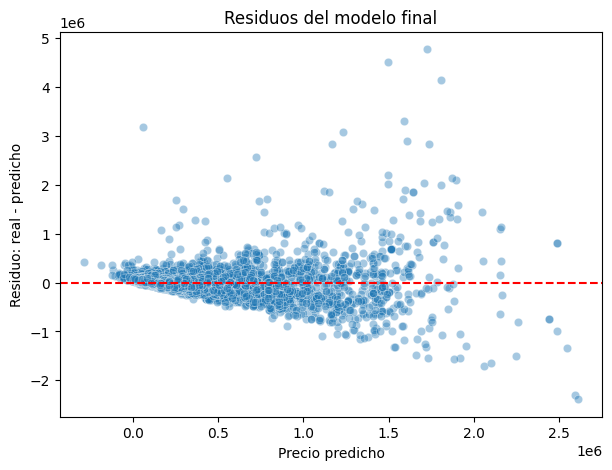

In [94]:
from sklearn.metrics import mean_absolute_error, median_absolute_error

residuos = y_test - y_pred

mae_test = mean_absolute_error(y_test, y_pred)
medae_test = median_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse_test:.2f}")
print(f"MAE: {mae_test:.2f}")
print(f"Error absoluto mediano: {medae_test:.2f}")
print(f"Residuo promedio: {residuos.mean():.2f}")

print(
    "Porcentaje de precios subestimados:",
    f"{(residuos > 0).mean() * 100:.2f}%"
)

print(
    "Porcentaje de precios sobreestimados:",
    f"{(residuos < 0).mean() * 100:.2f}%"
)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_pred,
    y=residuos,
    alpha=0.4
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Precio predicho")
plt.ylabel("Residuo: real - predicho")
plt.title("Residuos del modelo final")
plt.show()

El MAE fue de 75.480,06 y la mediana del error absoluto de 41.004,99 — bastante menor que el MAE, lo que indica que hay un grupo más chico de propiedades con errores muy grandes que arrastran el promedio hacia arriba. El residuo promedio fue de -2.925,26, cercano a cero, y el modelo subestimó el precio en el 49,19% de los casos y lo sobreestimó en el 50,81% — bastante equilibrado, sin sesgo sistemático fuerte hacia un lado.
En el gráfico de residuos vs. precio predicho se ve claramente que la dispersión crece a medida que aumenta el precio predicho: para propiedades más baratas los residuos están muy concentrados cerca de cero, mientras que para las más caras el error puede llegar a varios millones. Esto es heterocedasticidad, y significa que el modelo es bastante preciso para el segmento de precios más común, pero pierde mucha precisión en las propiedades de alto valor.

# 10. Resumen del proceso de Machine Learning (texto a completar)

Completen este texto que explica como se contruye estos modelos de ML.

Por favor, hagan una lista de las palabras:
eg: 1= XXXX; 2=XXXX...



El objetivo de este trabajo práctico es construir un modelo de __________ (1) para predecir el __________ (2) de una vivienda a partir de diferentes características del dataset.

Antes de entrenar un modelo de Machine Learning, es necesario realizar un __________ (3) del conjunto de datos para comprender su estructura. Para ello se utilizan funciones como __________ (4), __________ (5) y __________ (6), que permiten observar las primeras filas del dataset, los tipos de datos y las estadísticas descriptivas de cada variable.

Luego es importante verificar la presencia de __________ (7) en el dataset. Estos valores pueden ser eliminados o reemplazados mediante diferentes estrategias de __________ (8).

También se analizan las __________ (9) de las variables mediante gráficos como __________ (10) o __________ (11), lo que permite detectar posibles __________ (12) que podrían afectar el modelo.

Una vez comprendidas las variables, es útil analizar las __________ (13) entre ellas. Para ello se pueden utilizar gráficos de __________ (14) y matrices de __________ (15) que ayudan a identificar qué variables están más relacionadas con la variable objetivo.

En muchos datasets existen variables __________ (16) que no pueden ser utilizadas directamente por los modelos de Machine Learning. Por esta razón es necesario transformarlas mediante técnicas de __________ (17) como __________ (18) o __________ (19).

Una vez preparados los datos, el siguiente paso es separar el dataset en dos conjuntos: __________ (20) y __________ (21). Esta separación permite entrenar el modelo en un conjunto de datos y evaluar su rendimiento en datos que no ha visto previamente.

Después de la separación, se realiza el __________ (22) de las variables numéricas utilizando herramientas como __________ (23). Este paso es importante porque las variables pueden tener __________ (24) muy diferentes, lo que podría afectar el aprendizaje del modelo.

Es importante aplicar el escalado después de la separación de los datos para evitar el problema conocido como __________ (25).

Finalmente, se entrena un modelo de __________ (26) utilizando los datos de entrenamiento. Este modelo aprende una relación entre las variables de entrada y la variable objetivo, generalmente representada por una ecuación de la forma:
y=β0+β1x1+β2x2+...

donde __________ (27) representa la variable a predecir, __________ (28) son las variables explicativas y los coeficientes __________ (29) representan el impacto de cada variable en la predicción.

Una vez entrenado el modelo, su rendimiento se evalúa utilizando el conjunto de __________ (30) mediante métricas como __________ (31), __________ (32) o __________ (33).

Este proceso permite construir un modelo capaz de __________ (34) el precio de nuevas viviendas a partir de sus características.